In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
all_packets = pd.read_csv('packets.csv', index_col=0)
node1_packets = pd.read_csv('node1_packets.csv', index_col=0)
node2_packets = pd.read_csv('node2_packets.csv', index_col=0)
receiver_packets = pd.read_csv('receiver_packets.csv', index_col=0)

In [3]:
all_packets

,radio_id,start_time,airtime,location.x,location.y,tx_power,code_rate,spreading_factor,bandwidth,crc_enabled,preamble_len,fixed_len,iq_inverted,symbols,payload
id,,,,,,,,,,,,,,,
1,1,0.001002,0.041216,0.0,0.0,20,1,7,0,True,8,False,False,0,b'BeepBoop'
2,2,0.002002,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'
3,2,0.263218,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'
4,2,0.524435,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'
5,1,0.542218,0.041216,0.0,0.0,20,1,7,0,True,8,False,False,0,b'BeepBoop'
6,2,0.785652,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'
7,2,1.046869,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'
8,1,1.083434,0.041216,0.0,0.0,20,1,7,0,True,8,False,False,0,b'BeepBoop'
9,2,1.308086,0.041216,0.0,0.0,15,1,7,0,True,8,False,False,0,b'BeepBoop'


In [4]:
receiver_packets

,time,snr,rssi,collision,missed_start,missed_end,interrupted
id,,,,,,,
1,0.042218,140.0,20.0,True,False,False,NaN
2,0.043218,135.0,15.0,True,False,False,NaN
3,0.304434,135.0,15.0,False,False,False,NaN
4,0.565651,135.0,15.0,False,False,False,NaN
5,0.583434,140.0,20.0,True,False,False,NaN
6,0.826868,135.0,15.0,False,False,False,NaN
7,1.088085,135.0,15.0,False,False,False,NaN
8,1.124650,140.0,20.0,True,False,False,NaN
9,1.349302,135.0,15.0,False,False,False,NaN


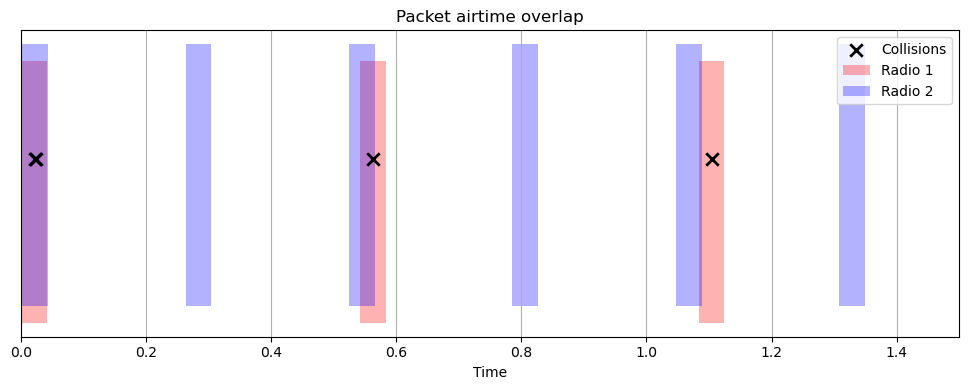

In [5]:
import matplotlib.pyplot as plt

all_packets['stop_time'] = all_packets['start_time'] + all_packets['airtime']


plt.figure(figsize=(10, 4))


r1 = all_packets[all_packets['radio_id'] == 1]
r2 = all_packets[all_packets['radio_id'] == 2]

plt.barh(
    y=1,
    width=r1['airtime'],
    left=r1['start_time'],
    label="Radio 1",
    color=(1,0,0,0.3)
)

plt.barh(
    y=1.05,
    width=r2['airtime'],
    left=r2['start_time'],
    label="Radio 2",
    color=(0,0,1,0.3)
)

collisions = receiver_packets[receiver_packets['collision']]
plt.scatter(
    collisions['time'] - 0.02,
    y=np.ones(len(collisions)) * 1.1,
    marker='x',
    s=80,
    linewidths=2,
    color='black',
    zorder=5,
    label="Collisions"
)

plt.xlabel("Time")
plt.xlim(0, 1.5)

plt.title("Packet airtime overlap")
plt.tight_layout()
plt.grid()
plt.yticks([])

plt.legend()

plt.show()

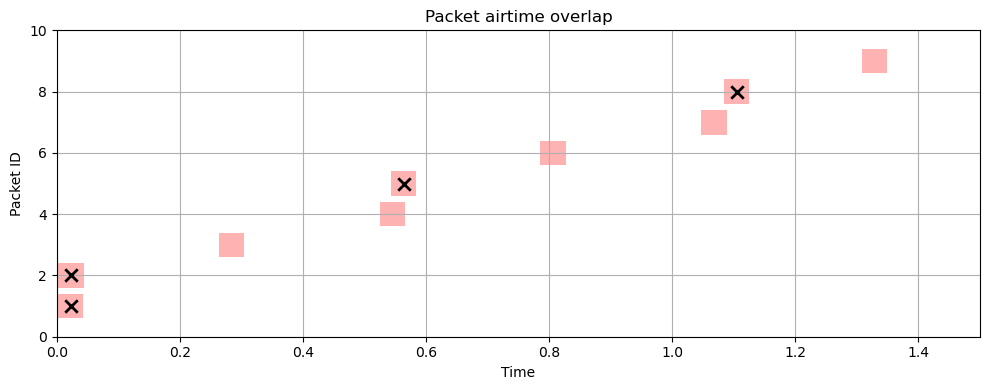

In [6]:
import matplotlib.pyplot as plt

all_packets['stop_time'] = all_packets['start_time'] + all_packets['airtime']


plt.figure(figsize=(10, 4))

r1 = all_packets[all_packets['radio_id'] == 1]
r2 = all_packets[all_packets['radio_id'] == 2]

plt.barh(
    y=all_packets.index,
    width=all_packets['airtime'],
    left=all_packets['start_time'],
    color=(1,0,0,0.3)
)

collisions = receiver_packets[receiver_packets['collision']]
plt.scatter(
    collisions['time'] - 0.02,
    y=collisions.index,
    marker='x',
    s=80,
    linewidths=2,
    color='black',
    zorder=5,
)

plt.xlabel("Time")
plt.xlim(0, 1.5)

plt.ylabel('Packet ID')
plt.ylim(0,10)

plt.title("Packet airtime overlap")
plt.tight_layout()
plt.grid()

plt.show()